In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv(r"C:\Users\dell\Desktop\Projects\HR Analytics Project\HR Analytics Cleaned.csv")

In [41]:
df.shape

(1470, 35)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   AgeGroup                  1470 non-null   str  
 2   Attrition                 1470 non-null   str  
 3   EmployeeStatus            1470 non-null   str  
 4   BusinessTravel            1470 non-null   str  
 5   DailyRate                 1470 non-null   int64
 6   Department                1470 non-null   str  
 7   DistanceFromHome          1470 non-null   int64
 8   Education                 1470 non-null   int64
 9   EducationField            1470 non-null   str  
 10  EmployeeCount             1470 non-null   int64
 11  EmployeeNumber            1470 non-null   int64
 12  EnvironmentSatisfaction   1470 non-null   int64
 13  Gender                    1470 non-null   str  
 14  HourlyRate                1470 non-null   int64
 15

In [43]:
df.head()

,Age,AgeGroup,Attrition,EmployeeStatus,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,35-44,Yes,Left,Travel_Rarely,1102,Sales,1,2,Life Sciences,...,3,1,0,8,0,1,6,4,0,5
1,49,45-54,No,Active,Travel_Frequently,279,Research & Development,8,1,Life Sciences,...,4,4,1,10,3,3,10,7,1,7
2,37,35-44,Yes,Left,Travel_Rarely,1373,Research & Development,2,2,Other,...,3,2,0,7,3,3,0,0,0,0
3,33,25-34,No,Active,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,...,3,3,0,8,3,3,8,7,3,0
4,27,25-34,No,Active,Travel_Rarely,591,Research & Development,2,1,Medical,...,3,4,1,6,3,3,2,2,2,2


In [44]:
df.isnull().sum()

Age                         0
AgeGroup                    0
Attrition                   0
EmployeeStatus              0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [47]:
attrition_rate = (df['Attrition'] == 'Yes').mean()*100
print("Overall attrition rate:",round(attrition_rate, 2),"%")

Overall attrition rate: 16.12 %


In [48]:
retention_rate = (df['Attrition'] == 'No').mean()*100
print("Overall retention rate:",round(retention_rate, 2),"%")

Overall retention rate: 83.88 %


In [49]:
attrition_summary = df['Attrition'].value_counts().reset_index()

attrition_summary.columns = ['Attrition', 'EmployeeCount']

attrition_summary

,Attrition,EmployeeCount
0,No,1233
1,Yes,237


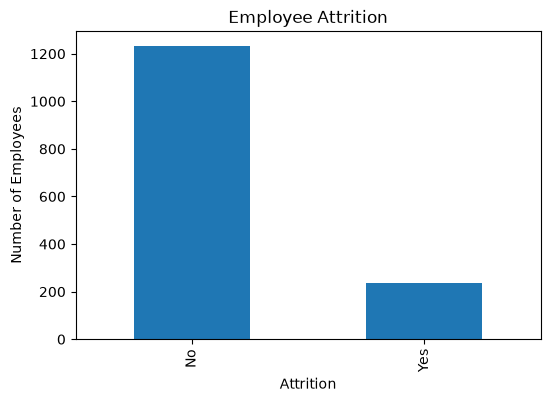

In [50]:
plt.figure(figsize=(6, 4))
df['Attrition'].value_counts().plot(kind='bar')
plt.title('Employee Attrition')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.show()

In [54]:
department_attrition = pd.crosstab(
    df['Department'], 
    df['Attrition']
)
department_attrition

Attrition,No,Yes
Department,,
Human Resources,55,8
Research & Development,808,153
Sales,370,76


In [55]:
department_rate = (
    (df['Attrition'] == 'Yes')
    .groupby(df['Department'])
    .mean() * 100
).round(2)
department_rate

Department
Human Resources           12.70
Research & Development    15.92
Sales                     17.04
Name: Attrition, dtype: float64

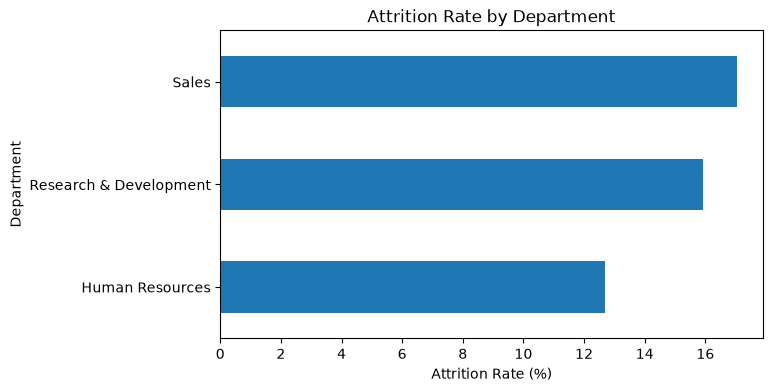

In [56]:
department_rate.sort_values().plot(kind='barh', figsize=(7, 4))

plt.title('Attrition Rate by Department')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Department')

plt.show()

In [58]:
jobrole_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition']
)

jobrole_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,111,20
Human Resources,46,6
Laboratory Technician,213,46
Manager,84,18
Manufacturing Director,127,18
Research Director,69,11
Research Scientist,242,50
Sales Executive,270,56
Sales Representative,71,12


In [59]:
jobrole_rate = (
    df.groupby('JobRole')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

jobrole_rate

JobRole
Healthcare Representative    15.27
Human Resources              11.54
Laboratory Technician        17.76
Manager                      17.65
Manufacturing Director       12.41
Research Director            13.75
Research Scientist           17.12
Sales Executive              17.18
Sales Representative         14.46
Name: Attrition, dtype: float64

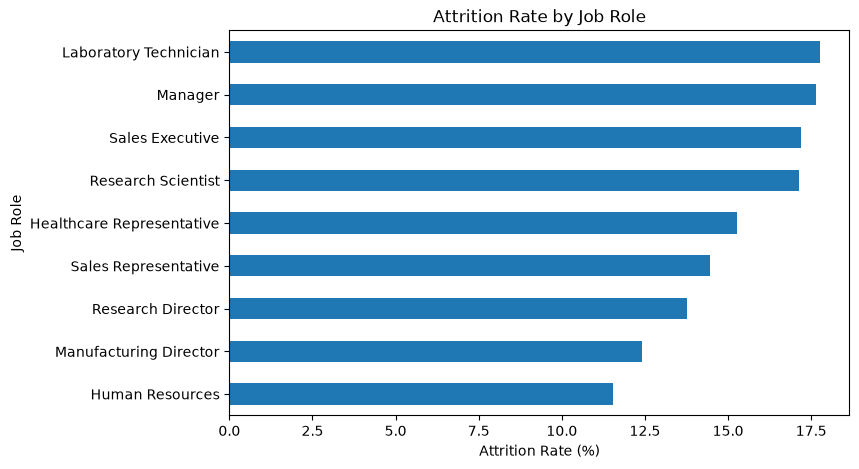

In [60]:
jobrole_rate.sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')

plt.show()

In [61]:
overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition']
)

overtime_attrition

Attrition,No,Yes
OverTime,,
No,879,175
Yes,354,62


In [62]:
overtime_rate = (
    df.groupby('OverTime')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

overtime_rate

OverTime
No     16.6
Yes    14.9
Name: Attrition, dtype: float64

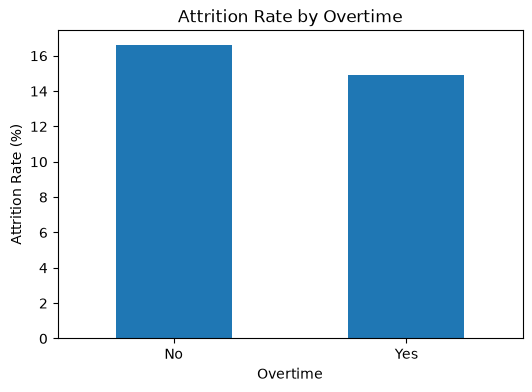

In [63]:
overtime_rate.plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=0)

plt.show()

In [64]:
satisfaction_rate = (
    df.groupby('JobSatisfaction')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

satisfaction_rate

JobSatisfaction
1    16.26
2    16.43
3    14.25
4    17.65
Name: Attrition, dtype: float64

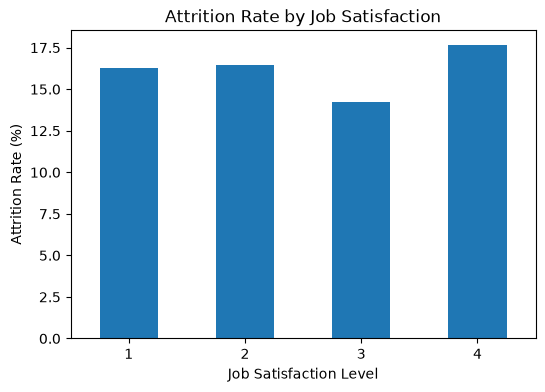

In [65]:
satisfaction_rate.plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Attrition Rate by Job Satisfaction')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=0)

plt.show()

In [66]:
worklife_rate = (
    df.groupby('WorkLifeBalance')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

worklife_rate

WorkLifeBalance
1    15.00
2    16.86
3    15.68
4    17.65
Name: Attrition, dtype: float64

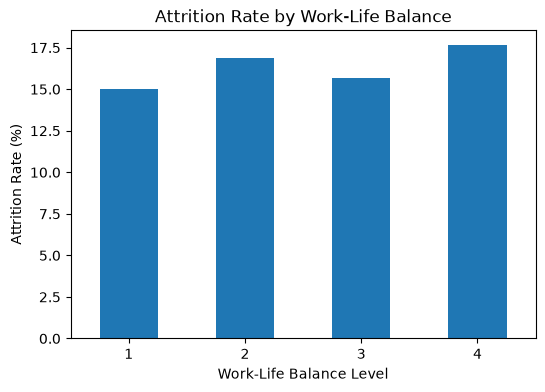

In [67]:
worklife_rate.plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Attrition Rate by Work-Life Balance')
plt.xlabel('Work-Life Balance Level')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=0)

plt.show()

In [68]:
df['SalaryRange'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0, 3000, 6000, 10000, float('inf')],
    labels=['Below 3000', '3000-5999', '6000-9999', '10000+']
)

In [71]:
salary_rate = (
    df.groupby('SalaryRange', observed=False)['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

salary_rate

SalaryRange
Below 3000    17.72
3000-5999     15.03
6000-9999     15.27
10000+        16.73
Name: Attrition, dtype: float64

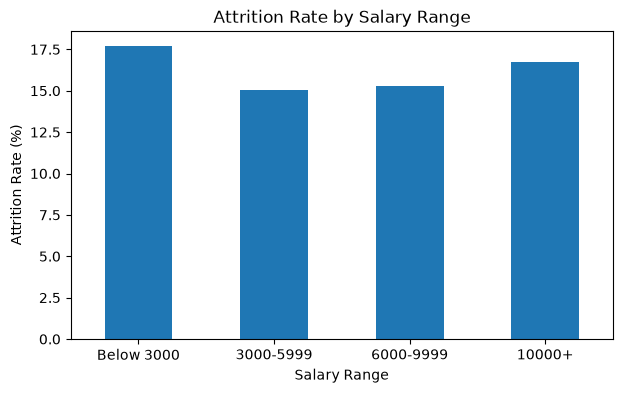

In [72]:
salary_rate.plot(
    kind='bar',
    figsize=(7, 4)
)

plt.title('Attrition Rate by Salary Range')
plt.xlabel('Salary Range')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=0)

plt.show()

In [73]:
df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 1, 4, 9, float('inf')],
    labels=['Less than 2 Years', '2-4 Years', '5-9 Years', '10+ Years']
)

In [74]:
tenure_rate = (
    df.groupby('TenureGroup', observed=False)['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

tenure_rate

TenureGroup
Less than 2 Years    15.81
2-4 Years            18.36
5-9 Years            14.50
10+ Years            16.39
Name: Attrition, dtype: float64

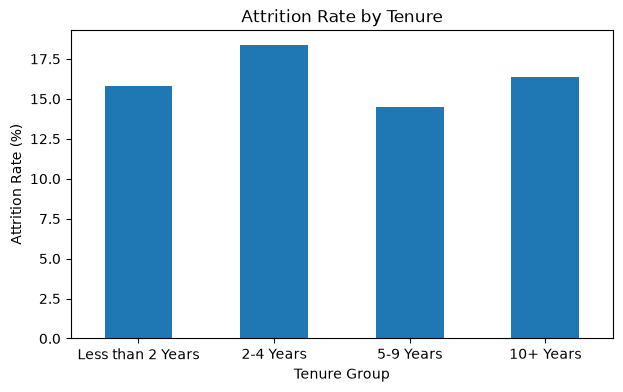

In [75]:
tenure_rate.plot(
    kind='bar',
    figsize=(7, 4)
)

plt.title('Attrition Rate by Tenure')
plt.xlabel('Tenure Group')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=0)

plt.show()

In [76]:
age_rate = (
    df.groupby('AgeGroup')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

age_rate

AgeGroup
25-34       16.43
35-44       16.44
45-54       15.92
55+         10.14
Under 25    17.53
Name: Attrition, dtype: float64

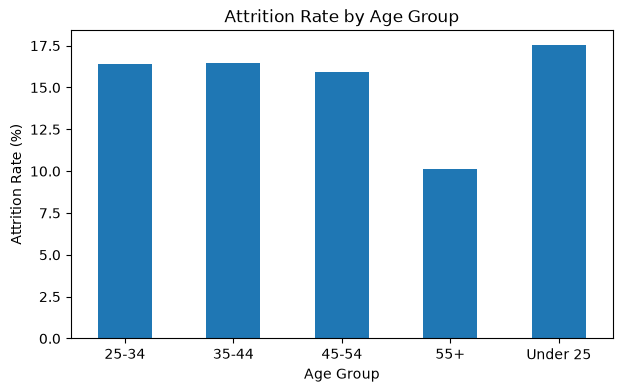

In [77]:
age_rate.plot(
    kind='bar',
    figsize=(7, 4)
)

plt.title('Attrition Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=0)

plt.show()

In [78]:
travel_rate = (
    df.groupby('BusinessTravel')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .round(2)
)

travel_rate

BusinessTravel
Non-Travel           20.67
Travel_Frequently    15.16
Travel_Rarely        15.72
Name: Attrition, dtype: float64

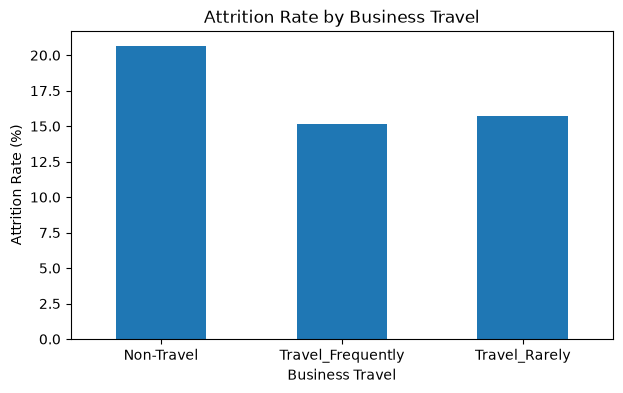

In [79]:
travel_rate.plot(
    kind='bar',
    figsize=(7, 4)
)

plt.title('Attrition Rate by Business Travel')
plt.xlabel('Business Travel')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=0)

plt.show()

In [80]:
summary = pd.DataFrame({
    'Metric': [
        'Total Employees',
        'Employees Left',
        'Employees Active',
        'Attrition Rate',
        'Retention Rate'
    ],
    
    'Value': [
        len(df),
        (df['Attrition'] == 'Yes').sum(),
        (df['Attrition'] == 'No').sum(),
        round((df['Attrition'] == 'Yes').mean() * 100, 2),
        round((df['Attrition'] == 'No').mean() * 100, 2)
    ]
})

summary

,Metric,Value
0,Total Employees,1470.00
1,Employees Left,237.00
2,Employees Active,1233.00
3,Attrition Rate,16.12
4,Retention Rate,83.88


In [81]:
df.to_csv('HR_Analytics_Final.csv', index=False)